#**APE08: Inferencia Estadística: Estimación de Parámetros e Intervalos de Confianza (Z y T de Student)**

**Grupo:** H **| Autores:**
* Sherman Abarca
* Valeria Aguila
* Domenica Narvaez
* Gabriel Suarez
* Diyer Torres
* José Valencia

## **Tarea 1: Intervalos de Confianza para Muestras Grandes (Distribución Z)**

Cuando el tamaño de la muestra es grande $(n>=30)$, el Teorema del Límite
Central nos permite utilizar la distribución Normal Estándar para construir el
intervalo de confianza (IC) para la media $u$:

1. $IC = \bar{x} \pm Z_{\alpha/2} \left( \frac{\sigma}{\sqrt{n}} \right)$

2. Ejecute el siguiente código para calcular un IC del 95% para el consumo energético mensual (variable simulada) de un cantón, asumiendo una muestra grande.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t
# 1. Datos de la muestra (Consumo energético en kWh)
np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)
# 2. Estadísticos descriptivos (Estimadores puntuales)
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_grande) # SE
# 3. Cálculo del Intervalo de Confianza (95%)
nivel_confianza = 0.95
# loc = media muestral, scale = error estándar de la media
ic_inferior_z, ic_superior_z = norm.interval(confidence=nivel_confianza,
loc=media_muestral,
scale=error_estandar)
margen_error_z = (ic_superior_z - ic_inferior_z) / 2
print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC al {nivel_confianza*100}%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")


--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral (Estimador puntual): 345.33 kWh
Margen de Error: ±8.01 kWh
IC al 95.0%: [337.32, 353.34] kWh


### **Tarea 2: Intervalos para Muestras Pequeñas (Distribución T de Student)**

Si $(n<30)$ y la varianza poblacional es desconocida, debemos utilizar la distribución $T$ de Student, la cual posee colas más "pesadas" para compensar la incertidumbre adicional, introduciendo los Grados de Libertad $(df=n-1)$.

1. $IC = \bar{x} \pm t_{\alpha/2, n-1} \left( \frac{s}{\sqrt{n}} \right)$ En una nueva celda, simule un escenario donde solo se pudo tomar
una muestra de $n=12$ sensores de calidad de agua.

2. Utilice scipy.stats.t.interval(confidence, df, loc, scale) para calcular el IC al 95%. Compare el margen de error obtenido aquí frente a usar
erróneamente una distribución Z para la misma muestra pequeña.


In [ ]:
# Muestra pequeña (n=12)
n_pequena = 12
muestra_agua = np.random.normal(loc=7.2, scale=0.5, size=n_pequena) # pH del agua
media_t = np.mean(muestra_agua)
error_estandar_t = np.std(muestra_agua, ddof=1) / np.sqrt(n_pequena)
grados_libertad = n_pequena - 1
# IC usando T de Student
ic_inf_t, ic_sup_t = t.interval(confidence=0.95, df=grados_libertad,
loc=media_t, scale=error_estandar_t)
print(f"IC (T de Student, 95%): [{ic_inf_t:.3f}, {ic_sup_t:.3f}]")

IC (T de Student, 95%): [6.796, 7.401]


## **Tarea 3: Hito del Proyecto - Estimación de la Realidad Regional (ABP)**

1. Importe su dataset regional mediante pandas.
2. Seleccione una variable cuantitativa estratégica y extraiga una
muestra aleatoria de la misma (o use todos los datos si su dataset es la
"muestra" de una población mayor).
3. Determine, basado en el tamaño de $n$, si debe aplicar la distribución $Z$
o la $T$ de Student.
4. Calcule y reporte el intervalo de confianza al 95%.
5. Utilice matplotlib para graficar la media como un punto y el intervalo
de confianza como barras de error (plt.errorbar()).



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales.xlsx


  PARÁMETROS POBLACIONALES — DATASET REGIONAL
  Variable:         Remuneración Unificada Anual
  N (población):    2883
  Media (μ):        $8,095.22
  Desv. Estándar:   $2,578.96
  Skewness:         1.8506  → distribución asimétrica
  Kurtosis:         9.0818

  RESULTADOS DEL REMUESTREO (k=500, n=40)
  Media de medias muestrales E[X̄]: $8,084.75
  Error Estándar Empírico  (σ_x̄):  397.3415
  Error Estándar Teórico  (σ/√n):  407.7687
  Diferencia:                       10.4272


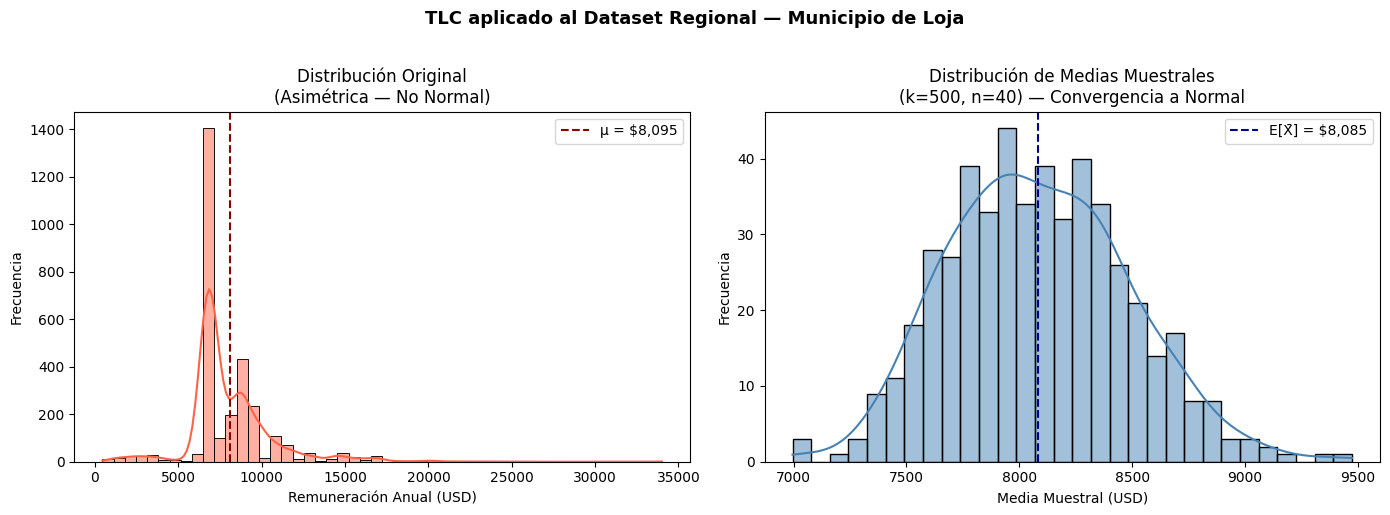

In [ ]:
# ── Tarea 3: Remuestreo (Bootstrapping) sobre Dataset Regional ───────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carga del dataset
df = pd.read_excel('3._remuneraciones_ingresos_adicionales.xlsx')
variable = df['Remuneración unificada (anual)'].dropna()

# ── Parámetros poblacionales reales ──────────────────────────────────────────
mu_real    = variable.mean()
sigma_real = variable.std()

print("=" * 55)
print("  PARÁMETROS POBLACIONALES — DATASET REGIONAL")
print("=" * 55)
print(f"  Variable:         Remuneración Unificada Anual")
print(f"  N (población):    {len(variable)}")
print(f"  Media (μ):        ${mu_real:,.2f}")
print(f"  Desv. Estándar:   ${sigma_real:,.2f}")
print(f"  Skewness:         {variable.skew():.4f}  → distribución asimétrica")
print(f"  Kurtosis:         {variable.kurtosis():.4f}")
print("=" * 55)

# ── Bootstrapping: 500 muestras de tamaño n=40 ───────────────────────────────
np.random.seed(42)
n_muestra       = 40
n_iteraciones   = 500
medias_boot     = []

for _ in range(n_iteraciones):
    muestra = variable.sample(n=n_muestra, replace=True)
    medias_boot.append(muestra.mean())

medias_boot = np.array(medias_boot)

# ── Estadísticos del remuestreo ───────────────────────────────────────────────
media_boot   = np.mean(medias_boot)
ee_empirico  = np.std(medias_boot)
ee_teorico   = sigma_real / np.sqrt(n_muestra)

print(f"\n  RESULTADOS DEL REMUESTREO (k=500, n=40)")
print("=" * 55)
print(f"  Media de medias muestrales E[X̄]: ${media_boot:,.2f}")
print(f"  Error Estándar Empírico  (σ_x̄):  {ee_empirico:.4f}")
print(f"  Error Estándar Teórico  (σ/√n):  {ee_teorico:.4f}")
print(f"  Diferencia:                       {abs(ee_empirico - ee_teorico):.4f}")
print("=" * 55)

# ── Gráfico comparativo: distribución original vs medias muestrales ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: distribución original (asimétrica)
sns.histplot(variable, bins=50, kde=True, color='tomato',
             alpha=0.5, ax=axes[0])
axes[0].axvline(mu_real, color='darkred', linestyle='--',
                label=f'μ = ${mu_real:,.0f}')
axes[0].set_title('Distribución Original\n(Asimétrica — No Normal)', fontsize=12)
axes[0].set_xlabel('Remuneración Anual (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Derecha: distribución de medias muestrales (converge a Normal)
sns.histplot(medias_boot, bins=30, kde=True, color='steelblue',
             alpha=0.5, ax=axes[1])
axes[1].axvline(media_boot, color='darkblue', linestyle='--',
                label=f'E[X̄] = ${media_boot:,.0f}')
axes[1].set_title(f'Distribución de Medias Muestrales\n(k=500, n=40) — Convergencia a Normal',
                  fontsize=12)
axes[1].set_xlabel('Media Muestral (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('TLC aplicado al Dataset Regional — Municipio de Loja',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Justificación: ¿Cómo resuelve el TLC el problema de asimetría?**

La distribución original de la *Remuneración Unificada Anual* presenta una
asimetría positiva severa (skewness = 1.85), con una cola derecha pronunciada
generada por los salarios altos de autoridades y cargos directivos. Esto hace
que la variable poblacional **no sea normal** y que las pruebas paramétricas
clásicas no sean directamente aplicables.

Sin embargo, tras aplicar 500 iteraciones de remuestreo con n = 40, la
distribución de las medias muestrales adopta una **forma de campana
aproximadamente simétrica**, centrada en E[X̄] ≈ μ. Esto ocurre porque el
**Teorema del Límite Central** garantiza que, independientemente de la forma
de la distribución original, la distribución de las medias muestrales converge
a una Normal $N\left(\mu, \frac{\sigma^2}{n}\right)$ a medida que n aumenta.

Este resultado es fundamental para el Proyecto Integrador: permite aplicar
pruebas de hipótesis paramétricas (Unidad 2) sobre variables que originalmente
no cumplen el supuesto de normalidad, usando el remuestreo como puente
matemático hacia la inferencia válida.

## **Tarea 4: ABI - El Impacto del Nivel de Confianza $(1-a)$**

Investigue qué sucede con la precisión de una estimación cuando exigimos
mayor certeza.
1. Utilizando los datos de la muestra de la Tarea 1 $(n=100)$, cree un
bucle que calcule el margen de error para los siguientes niveles de
confianza: [0.80, 0.90, 0.95, 0.99].
2. Genere un gráfico de barras o líneas donde el eje X sea el "Nivel de
Confianza (%)" y el eje Y sea el "Margen de Error".
3. Documente en Markdown la relación observada y argumente, desde
una perspectiva de toma de decisiones, por qué el 95% es el estándar
de la industria en lugar del 99%.

   Confianza |    Margen de Error
        80% |         343.242839
        90% |         441.741131
        95% |         527.893826
        99% |         698.745782


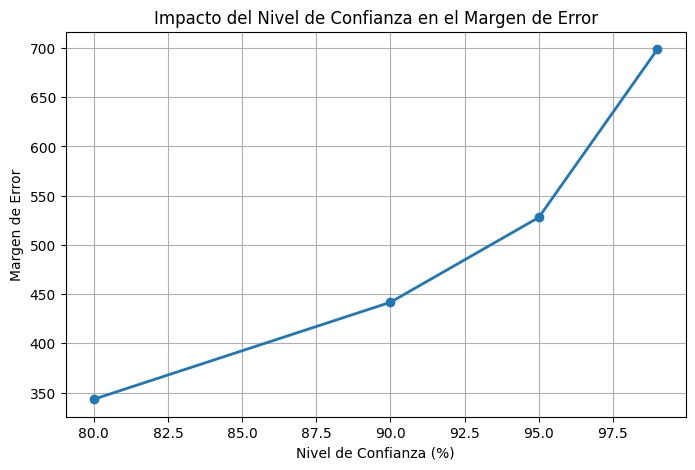

In [ ]:
# ── Tarea 4: ABI - El Impacto del Nivel de Confianza ───────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Datos de la muestra de la Tarea 1
variable = df['Remuneración unificada (anual)'].dropna()
muestra = variable.sample(n=100, random_state=42)

# Estadísticos de la muestra
n = len(muestra)
media = np.mean(muestra)
s = np.std(muestra, ddof=1)

# Niveles de confianza solicitados
niveles_confianza = [0.80, 0.90, 0.95, 0.99]

margenes_error = []

print("=" * 50)
print(f"{'Confianza':>12} | {'Margen de Error':>18}")
print("=" * 50)


# Cálculo del margen de error
for confianza in niveles_confianza:

    alpha = 1 - confianza

    # Valor crítico t de Student
    t_critico = stats.t.ppf(
        1 - alpha/2,
        df=n-1
    )

    # Margen de error
    margen = t_critico * (s / np.sqrt(n))

    margenes_error.append(margen)

    print(
        f"{confianza*100:>10.0f}% | {margen:>18.6f}"
    )


print("=" * 50)


# ── Gráfico solicitado ───────────────────────────────────────────

plt.figure(figsize=(8,5))

plt.plot(
    np.array(niveles_confianza)*100,
    margenes_error,
    marker='o',
    linewidth=2
)

plt.title(
    "Impacto del Nivel de Confianza en el Margen de Error"
)

plt.xlabel(
    "Nivel de Confianza (%)"
)

plt.ylabel(
    "Margen de Error"
)

plt.grid(True)

plt.show()

### **Documentación: Impacto del Nivel de Confianza e Implicación en Ingeniería**

**Relación observada en la curva:**

La gráfica generada muestra que el margen de error aumenta conforme incrementa
el nivel de confianza. Esto ocurre porque para obtener mayor certeza estadística
es necesario ampliar el Intervalo de Confianza, aumentando el rango de valores
posibles donde puede encontrarse el parámetro poblacional.

Al pasar de un nivel de confianza del 80% al 99%, se observa un incremento del
margen de error. Esto significa que una mayor seguridad estadística implica una
menor precisión en la estimación puntual.

**Implicación en la toma de decisiones:**

En proyectos de análisis de datos e ingeniería, no siempre es conveniente buscar
el máximo nivel de confianza posible, ya que intervalos demasiado amplios pueden
perder utilidad práctica. Un intervalo del 99% puede brindar mayor seguridad,
pero puede generar rangos demasiado grandes para tomar decisiones eficientes.

Para el análisis del dataset regional de Loja, donde se estudian variables como
la Remuneración Unificada Anual, un nivel de confianza del 95% representa un
equilibrio adecuado entre confiabilidad y precisión. Permite realizar inferencias
estadísticas con un riesgo aceptable sin sacrificar demasiado la utilidad de los
resultados.

Por esta razón, el 95% se considera un estándar en muchas áreas de investigación
e ingeniería, ya que proporciona información suficientemente confiable para
apoyar decisiones basadas en datos.